In [1]:
import os
print(os.getcwd())

/Users/lea/Documents/Projects/movie-recommender/notebooks


In [2]:
import os

if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

print("Working directory is now:", os.getcwd())

Working directory is now: /Users/lea/Documents/Projects/movie-recommender


In [3]:
import pandas as pd

# MovieLens
ratings = pd.read_csv('data/ratings.csv')
links_ml = pd.read_csv('data/links_movielens.csv')

# Kaggle
movies = pd.read_csv('data/movies_metadata.csv', low_memory=False)
keywords = pd.read_csv('data/keywords.csv')
credits = pd.read_csv('data/credits.csv')
links_kaggle = pd.read_csv('data/links_kaggle.csv')

In [4]:
for name, df in [('ratings', ratings), ('links_ml', links_ml), 
                  ('movies', movies), ('keywords', keywords), 
                  ('credits', credits), ('links_kaggle', links_kaggle)]:
    print(f"{name}: {df.shape}")

ratings: (100836, 4)
links_ml: (9742, 3)
movies: (45466, 24)
keywords: (46419, 2)
credits: (45476, 3)
links_kaggle: (45843, 3)


In [5]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB


In [6]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45466 entries, 0 to 45465
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  45466 non-null  object 
 1   belongs_to_collection  4494 non-null   object 
 2   budget                 45466 non-null  object 
 3   genres                 45466 non-null  object 
 4   homepage               7782 non-null   object 
 5   id                     45466 non-null  object 
 6   imdb_id                45449 non-null  object 
 7   original_language      45455 non-null  object 
 8   original_title         45466 non-null  object 
 9   overview               44512 non-null  object 
 10  popularity             45461 non-null  object 
 11  poster_path            45080 non-null  object 
 12  production_companies   45463 non-null  object 
 13  production_countries   45463 non-null  object 
 14  release_date           45379 non-null  object 
 15  re

In [7]:
movies[pd.to_numeric(movies['id'], errors='coerce').isna()] #converts id to number + checks for NaN values 

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
19730,- Written by Ørnås,0.065736,/ff9qCepilowshEtG2GYWwzt2bs4.jpg,"[{'name': 'Carousel Productions', 'id': 11176}...","[{'iso_3166_1': 'CA', 'name': 'Canada'}, {'iso...",1997-08-20,0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
29503,Rune Balot goes to a casino connected to the ...,1.931659,/zV8bHuSL6WXoD6FWogP9j4x80bL.jpg,"[{'name': 'Aniplex', 'id': 2883}, {'name': 'Go...","[{'iso_3166_1': 'US', 'name': 'United States o...",2012-09-29,0,68.0,"[{'iso_639_1': 'ja', 'name': '日本語'}]",Released,...,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
35587,Avalanche Sharks tells the story of a bikini ...,2.185485,/zaSf5OG7V8X8gqFvly88zDdRm46.jpg,"[{'name': 'Odyssey Media', 'id': 17161}, {'nam...","[{'iso_3166_1': 'CA', 'name': 'Canada'}]",2014-01-01,0,82.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,...,22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
keywords.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46419 entries, 0 to 46418
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        46419 non-null  int64 
 1   keywords  46419 non-null  object
dtypes: int64(1), object(1)
memory usage: 725.4+ KB


In [9]:
credits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45476 entries, 0 to 45475
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   cast    45476 non-null  object
 1   crew    45476 non-null  object
 2   id      45476 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 1.0+ MB


In [10]:
links_kaggle.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45843 entries, 0 to 45842
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   movieId  45843 non-null  int64  
 1   imdbId   45843 non-null  int64  
 2   tmdbId   45624 non-null  float64
dtypes: float64(1), int64(2)
memory usage: 1.0 MB


In [11]:
ratings['rating'].describe()

count    100836.000000
mean          3.501557
std           1.042529
min           0.500000
25%           3.000000
50%           3.500000
75%           4.000000
max           5.000000
Name: rating, dtype: float64

In [12]:
n_users = ratings['userId'].nunique()
n_movies = ratings['movieId'].nunique()
n_ratings = len(ratings)

sparsity = 1 - (n_ratings / (n_users * n_movies))

print(f"Users: {n_users}")
print(f"Movies rated: {n_movies}")
print(f"Total ratings: {n_ratings}")
print(f"Sparsity: {sparsity:.4%}")

Users: 610
Movies rated: 9724
Total ratings: 100836
Sparsity: 98.3000%


In [13]:
ratings_per_user = ratings.groupby('userId').size()
ratings_per_movie = ratings.groupby('movieId').size()

print("Ratings per user:")
print(ratings_per_user.describe())

print("\nRatings per movie:")
print(ratings_per_movie.describe())

Ratings per user:
count     610.000000
mean      165.304918
std       269.480584
min        20.000000
25%        35.000000
50%        70.500000
75%       168.000000
max      2698.000000
dtype: float64

Ratings per movie:
count    9724.000000
mean       10.369807
std        22.401005
min         1.000000
25%         1.000000
50%         3.000000
75%         9.000000
max       329.000000
dtype: float64


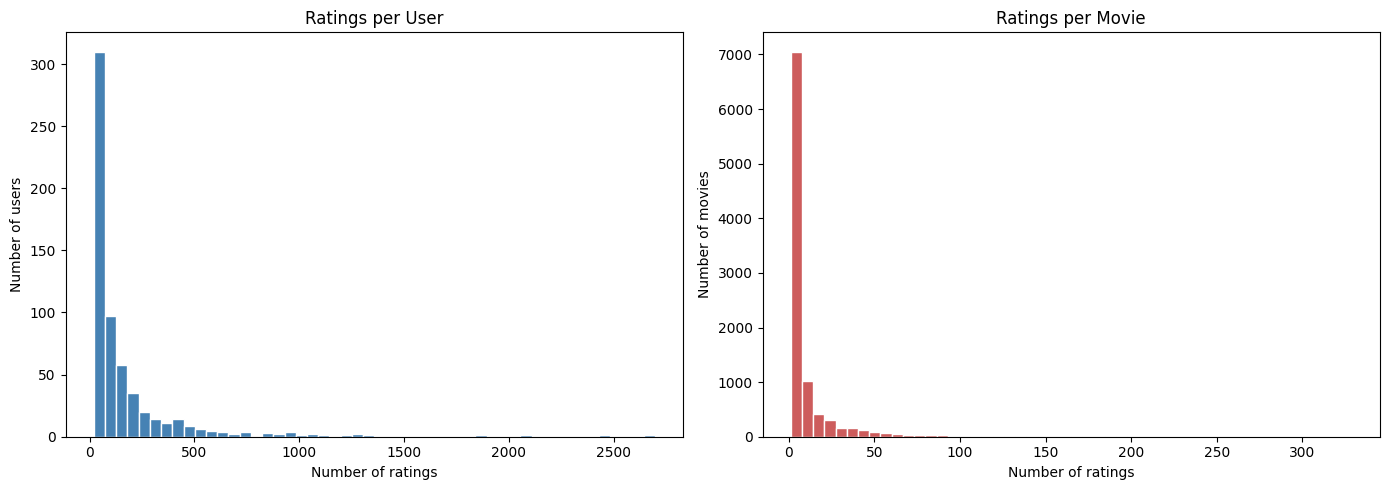

In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(ratings_per_user, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Ratings per User')
axes[0].set_xlabel('Number of ratings')
axes[0].set_ylabel('Number of users')

axes[1].hist(ratings_per_movie, bins=50, color='indianred', edgecolor='white')
axes[1].set_title('Ratings per Movie')
axes[1].set_xlabel('Number of ratings')
axes[1].set_ylabel('Number of movies')

plt.tight_layout()
plt.savefig('images/ratings_distribution.png', dpi=150)
plt.show()

In [15]:
movies['genres'].iloc[0]

"[{'id': 16, 'name': 'Animation'}, {'id': 35, 'name': 'Comedy'}, {'id': 10751, 'name': 'Family'}]"

In [16]:
movies['genres'].apply(type).value_counts()

genres
<class 'str'>    45466
Name: count, dtype: int64

In [17]:
movies['overview'].iloc[0]

"Led by Woody, Andy's toys live happily in his room until Andy's birthday brings Buzz Lightyear onto the scene. Afraid of losing his place in Andy's heart, Woody plots against Buzz. But when circumstances separate Buzz and Woody from their owner, the duo eventually learns to put aside their differences."

In [18]:
movies[movies['overview'].isna()][['title', 'release_date', 'vote_count']].head(10)

,title,release_date,vote_count
32,Wings of Courage,1996-09-18,4.0
300,Roommates,1995-03-01,7.0
634,Peanuts – Die Bank zahlt alles,1996-03-21,1.0
635,Happy Weekend,1996-03-14,0.0
641,The Superwife,1996-03-06,7.0
644,Und keiner weint mir nach,1996-02-29,0.0
679,Under The Domim Tree,1994-01-01,2.0
792,A Boy Called Hate,1996-05-22,2.0
802,Diebinnen,1996-06-20,1.0
821,The Day the Sun Turned Cold,1994-01-01,2.0


## Day 2 Findings 

**Ratings data:**
- 610 users, 9,724 rated movies, 100,836 ratings
- 98.3% sparsity in the user-item matrix
- Both ratings-per-user and ratings-per-movie are heavily right-skewed
  (median 70.5 vs mean 165.3 per user; median 3 vs mean 10.4 per movie)
- ~25% of movies have only 1 rating → collaborative filtering alone
  can't handle the long tail → empirical case for hybrid approach

**Movies metadata:**
- `id` column has 3 corrupted rows (shifted columns) → drop before Day 4 merge
- `genres` is a stringified list of dicts, 100% consistent format → parse later
- `overview` has 954 nulls, clustered in obscure/low-vote-count movies →
  low-impact, fallback to tagline/genres planned

**Links:**
- `links_kaggle.tmdbId` has 219 nulls → ~2% of MovieLens movies won't
  join to Kaggle metadata

In [19]:
print(movies.shape)
print(ratings.shape)

(45466, 24)
(100836, 4)


In [20]:
import ast

# Parse just for exploration - doesn't touch the original column
genre_lists = movies['genres'].apply(ast.literal_eval)
all_genres = genre_lists.explode()

genre_names = all_genres.apply(lambda x: x['name'] if isinstance(x, dict) else None)
genre_names.value_counts().head(20)

genres
Drama              20265
Comedy             13182
Thriller            7624
Romance             6735
Action              6596
Horror              4673
Crime               4307
Documentary         3932
Adventure           3496
Science Fiction     3049
Family              2770
Mystery             2467
Fantasy             2313
Animation           1935
Foreign             1622
Music               1598
History             1398
War                 1323
Western             1042
TV Movie             767
Name: count, dtype: int64

In [21]:
genre_lists.apply(len).describe()

count    45466.000000
mean         2.003827
std          1.131100
min          0.000000
25%          1.000000
50%          2.000000
75%          3.000000
max          8.000000
Name: genres, dtype: float64

In [22]:
movies['release_date'] = pd.to_datetime(movies['release_date'], errors='coerce')
movies['release_date'].dt.year.describe()

count    45376.000000
mean      1991.881193
std         24.055360
min       1874.000000
25%       1978.000000
50%       2001.000000
75%       2010.000000
max       2020.000000
Name: release_date, dtype: float64

In [23]:
movies[movies['release_date'].dt.year < 1900][['title', 'release_date', 'vote_count']]

,title,release_date,vote_count
16252,The Four Troublesome Heads,1898-01-01,19.0
16257,The Human Pyramid,1899-05-20,2.0
17569,Edison Kinetoscopic Record of a Sneeze,1894-01-09,12.0
18914,"Ella Lola, a la Trilby",1898-01-01,1.0
18944,"Turkish Dance, Ella Lola",1898-09-30,2.0
...,...,...,...
45259,The Astronomer's Dream,1898-01-01,26.0
45262,The Temptation of St. Anthony,1898-01-01,6.0
45263,An Up-to-Date Conjurer,1899-01-01,12.0
45334,The Devil in a Convent,1899-01-01,10.0


In [24]:
movies[movies['release_date'].dt.year < 1890][['title', 'release_date', 'vote_count']]

,title,release_date,vote_count
34933,Man Walking Around a Corner,1887-08-18,17.0
34934,Accordion Player,1888-01-01,18.0
34937,Sallie Gardner at a Gallop,1878-06-14,25.0
34938,Traffic Crossing Leeds Bridge,1888-10-15,25.0
34940,Passage of Venus,1874-12-09,19.0
41602,Buffalo Running,1883-11-19,7.0


In [25]:
keywords['keywords'].iloc[0]

"[{'id': 931, 'name': 'jealousy'}, {'id': 4290, 'name': 'toy'}, {'id': 5202, 'name': 'boy'}, {'id': 6054, 'name': 'friendship'}, {'id': 9713, 'name': 'friends'}, {'id': 9823, 'name': 'rivalry'}, {'id': 165503, 'name': 'boy next door'}, {'id': 170722, 'name': 'new toy'}, {'id': 187065, 'name': 'toy comes to life'}]"

In [26]:
keyword_lists = keywords['keywords'].apply(ast.literal_eval)
keyword_lists.apply(len).describe()


count    46419.000000
mean         3.418428
std          4.670315
min          0.000000
25%          0.000000
50%          2.000000
75%          5.000000
max        149.000000
Name: keywords, dtype: float64

In [27]:
(keyword_lists.apply(len) == 0).sum()

14795

In [28]:
credits['crew'].iloc[0]

'[{\'credit_id\': \'52fe4284c3a36847f8024f49\', \'department\': \'Directing\', \'gender\': 2, \'id\': 7879, \'job\': \'Director\', \'name\': \'John Lasseter\', \'profile_path\': \'/7EdqiNbr4FRjIhKHyPPdFfEEEFG.jpg\'}, {\'credit_id\': \'52fe4284c3a36847f8024f4f\', \'department\': \'Writing\', \'gender\': 2, \'id\': 12891, \'job\': \'Screenplay\', \'name\': \'Joss Whedon\', \'profile_path\': \'/dTiVsuaTVTeGmvkhcyJvKp2A5kr.jpg\'}, {\'credit_id\': \'52fe4284c3a36847f8024f55\', \'department\': \'Writing\', \'gender\': 2, \'id\': 7, \'job\': \'Screenplay\', \'name\': \'Andrew Stanton\', \'profile_path\': \'/pvQWsu0qc8JFQhMVJkTHuexUAa1.jpg\'}, {\'credit_id\': \'52fe4284c3a36847f8024f5b\', \'department\': \'Writing\', \'gender\': 2, \'id\': 12892, \'job\': \'Screenplay\', \'name\': \'Joel Cohen\', \'profile_path\': \'/dAubAiZcvKFbboWlj7oXOkZnTSu.jpg\'}, {\'credit_id\': \'52fe4284c3a36847f8024f61\', \'department\': \'Writing\', \'gender\': 0, \'id\': 12893, \'job\': \'Screenplay\', \'name\': \'A

In [29]:
def get_director_count(crew_str):
    crew_list = ast.literal_eval(crew_str)
    directors = [person['name'] for person in crew_list if person['job'] == 'Director']
    return len(directors)

director_counts = credits['crew'].apply(get_director_count)
director_counts.value_counts().sort_index()

crew
0       887
1     41389
2      2719
3       282
4        75
5        39
6        23
7        19
8        10
9         4
10        7
11        6
12        4
13        1
14        2
15        1
21        1
26        1
27        1
30        2
36        1
41        1
42        1
Name: count, dtype: int64

In [30]:
movies[['runtime', 'vote_average']].describe()

,runtime,vote_average
count,45203.000000,45460.000000
mean,94.128199,5.618207
std,38.407810,1.924216
min,0.000000,0.000000
25%,85.000000,5.000000
50%,95.000000,6.000000
75%,107.000000,6.800000
max,1256.000000,10.000000


In [31]:
print("Movies with vote_average of 0:", (movies['vote_average'] == 0).sum())
print("Of those, movies with vote_count of 0 too:", ((movies['vote_average'] == 0) & (movies['vote_count'] == 0)).sum())

print("\nMovies with runtime of 0:", (movies['runtime'] == 0).sum())

Movies with vote_average of 0: 2998
Of those, movies with vote_count of 0 too: 2899

Movies with runtime of 0: 1558


In [32]:
movies['id'].duplicated().sum()

30

In [33]:
dup_ids = movies[movies['id'].duplicated(keep=False)].sort_values('id')
dup_ids[['id', 'title', 'release_date']].head(20)

,id,title,release_date
676,105045,The Promise,1995-02-16
1465,105045,The Promise,1995-02-16
44821,10991,Pokémon: Spell of the Unknown,2000-07-08
4114,10991,Pokémon: Spell of the Unknown,2000-07-08
5710,109962,Rich and Famous,1981-09-23
20899,109962,Rich and Famous,1981-09-23
23534,110428,Camille Claudel 1915,2013-03-13
4356,110428,Camille Claudel 1915,2013-03-13
24844,11115,Deal,2008-01-29
14012,11115,Deal,2008-01-29


## Day 3 Findings 

**Genres:**
- Avg ~2 genres per movie; Drama (20,265) and Comedy (13,182) dominate
- Confirms only genre is too coarse a signal for mood/concept-based differentiation

**Keywords:**
- ~32% of movies (14,795) don't have keywords = useful enhancer, not a
  reliable signal for the content-based engine

**Credits (director):**
- ~91% of movies have 1 director (clean, expected case)
- 887 movies have zero directors listed = needs fallback
- Small number of outliers (up to 42 "directors") = likely data quality
  issues, will cap director count during Day 7 extraction

**Release dates:**
- Early dates (1874-1899) are real historical/proto-cinema footage,
  not corrupted data = scoping decision for later, not a cleanup task

**Runtime & vote_average:**
- Both have 0-value placeholders representing "missing," not genuine
  zero values (confirmed via vote_count correlation) = treat as
  null-equivalent if used as features

**Duplicate IDs:**
- 30 duplicate rows (15 movies, each listed twice) — genuine exact
  duplicates, safe to drop with `drop_duplicates(subset='id')` before
  the Day 4 merge
  

In [34]:
# Confirm the corrupted rows are still there from Day 2
corrupted_mask = pd.to_numeric(movies['id'], errors='coerce').isna()
print("Corrupted rows found:", corrupted_mask.sum())

movies_clean = movies[~corrupted_mask].copy()
print("Shape before:", movies.shape)
print("Shape after dropping corrupted rows:", movies_clean.shape)

Corrupted rows found: 3
Shape before: (45466, 24)
Shape after dropping corrupted rows: (45463, 24)


In [35]:
movies_clean['id'] = movies_clean['id'].astype(int)
movies_clean['id'].dtype

dtype('int64')

In [36]:
print("Shape before:", movies_clean.shape)

movies_clean = movies_clean.drop_duplicates(subset='id', keep='first')

print("Shape after dropping duplicates:", movies_clean.shape)

Shape before: (45463, 24)
Shape after dropping duplicates: (45433, 24)


In [37]:
# Hop 1: ratings -> links_kaggle (bring in tmdbId for each rating's movieId)
ratings_with_tmdb = ratings.merge(links_kaggle, on='movieId', how='left')
print("ratings_with_tmdb shape:", ratings_with_tmdb.shape)
print("Missing tmdbId after merge:", ratings_with_tmdb['tmdbId'].isna().sum())

ratings_with_tmdb shape: (100836, 6)
Missing tmdbId after merge: 363


In [38]:
# How many *movies* (not ratings) have a missing tmdbId in this merged data
ratings_with_tmdb[ratings_with_tmdb['tmdbId'].isna()]['movieId'].nunique()

165

In [39]:
# tmdbId is currently a float (due to NaNs), movies_clean.id is int - need matching types
ratings_with_tmdb['tmdbId'] = ratings_with_tmdb['tmdbId'].astype('Int64')  # nullable integer type

merged = ratings_with_tmdb.merge(
    movies_clean, 
    left_on='tmdbId', 
    right_on='id', 
    how='left'
)

print("merged shape:", merged.shape)
print("Ratings with no matching movie metadata:", merged['title'].isna().sum())

merged shape: (100836, 30)
Ratings with no matching movie metadata: 506


In [40]:
# How many unique movies (not ratings) are affected overall
merged[merged['title'].isna()]['movieId'].nunique()

# As a percentage of all ratings
print(f"{merged['title'].isna().sum() / len(merged):.2%} of ratings have no movie metadata")

0.50% of ratings have no movie metadata


In [41]:
merged[merged['title'].isna()]['movieId'].nunique()


198

In [42]:
# Check Toy Story specifically 
toy_story_check = merged[merged['movieId'] == 1][['userId', 'movieId', 'rating', 'tmdbId', 'title', 'genres']].head(5)
toy_story_check

,userId,movieId,rating,tmdbId,title,genres
0,1,1,4.0,862,Toy Story,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '..."
516,5,1,4.0,862,Toy Story,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '..."
874,7,1,4.5,862,Toy Story,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '..."
1434,15,1,2.5,862,Toy Story,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '..."
1667,17,1,4.5,862,Toy Story,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '..."


In [43]:
# Merge keywords
merged = merged.merge(keywords, on='id', how='left')

# Merge credits  
merged = merged.merge(credits, on='id', how='left')

print("Final merged shape:", merged.shape)
print(merged.columns.tolist())

Final merged shape: (101061, 33)
['userId', 'movieId', 'rating', 'timestamp', 'imdbId', 'tmdbId', 'adult', 'belongs_to_collection', 'budget', 'genres', 'homepage', 'id', 'imdb_id', 'original_language', 'original_title', 'overview', 'popularity', 'poster_path', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'video', 'vote_average', 'vote_count', 'keywords', 'cast', 'crew']


In [44]:
#Check whether there are any duplicate ids in the keywords and credits datasets
print("Duplicate ids in keywords:", keywords['id'].duplicated().sum())
print("Duplicate ids in credits:", credits['id'].duplicated().sum())

Duplicate ids in keywords: 987
Duplicate ids in credits: 44


In [45]:
# Check a sample of keywords duplicates
dup_keyword_ids = keywords[keywords['id'].duplicated(keep=False)]['id'].unique()[:3]
keywords[keywords['id'].isin(dup_keyword_ids)].sort_values('id')

,id,keywords
949,22649,"[{'id': 131, 'name': 'italy'}, {'id': 428, 'na..."
15074,22649,"[{'id': 131, 'name': 'italy'}, {'id': 428, 'na..."
676,105045,"[{'id': 7059, 'name': 'anti-communism'}, {'id'..."
1465,105045,"[{'id': 7059, 'name': 'anti-communism'}, {'id'..."
838,132641,"[{'id': 818, 'name': 'based on novel'}, {'id':..."
29999,132641,"[{'id': 818, 'name': 'based on novel'}, {'id':..."


In [46]:
dup_credit_ids = credits[credits['id'].duplicated(keep=False)]['id'].unique()[:3]
credits[credits['id'].isin(dup_credit_ids)].sort_values('id')

,cast,crew,id
949,"[{'cast_id': 1, 'character': 'Catherine Barkle...","[{'credit_id': '56d73d3e9251414291002436', 'de...",22649
15074,"[{'cast_id': 1, 'character': 'Catherine Barkle...","[{'credit_id': '56d73d3e9251414291002436', 'de...",22649
676,"[{'cast_id': 5, 'character': 'Sophie II', 'cre...","[{'credit_id': '52fe4a44c3a36847f81c463f', 'de...",105045
1465,"[{'cast_id': 5, 'character': 'Sophie II', 'cre...","[{'credit_id': '52fe4a44c3a36847f81c463f', 'de...",105045
838,"[{'cast_id': 4, 'character': 'Mihoko Nakagawa'...","[{'credit_id': '52fe4b9ac3a368484e190d25', 'de...",132641
30013,"[{'cast_id': 4, 'character': 'Mihoko Nakagawa'...","[{'credit_id': '56365ed9925141285701b06e', 'de...",132641


In [47]:
dupe_132641 = credits[credits['id'] == 132641]

for idx, row in dupe_132641.iterrows():
    print(f"--- Row index {idx} ---")
    crew_list = ast.literal_eval(row['crew'])
    print(f"Number of crew members: {len(crew_list)}")
    directors = [p['name'] for p in crew_list if p['job'] == 'Director']
    print(f"Directors: {directors}")
    print()

--- Row index 838 ---
Number of crew members: 12
Directors: ['Mikio Naruse']

--- Row index 30013 ---
Number of crew members: 12
Directors: ['Mikio Naruse']



In [48]:
keywords_clean = keywords.drop_duplicates(subset='id', keep='first')
credits_clean = credits.drop_duplicates(subset='id', keep='first')

print("keywords:", keywords.shape, "->", keywords_clean.shape)
print("credits:", credits.shape, "->", credits_clean.shape)

keywords: (46419, 2) -> (45432, 2)
credits: (45476, 3) -> (45432, 3)


In [49]:
# Rebuild the merge chain using the cleaned keywords/credits
merged = ratings_with_tmdb.merge(
    movies_clean, 
    left_on='tmdbId', 
    right_on='id', 
    how='left'
)

merged = merged.merge(keywords_clean, on='id', how='left')
merged = merged.merge(credits_clean, on='id', how='left')

print("Final merged shape:", merged.shape)

Final merged shape: (100836, 33)


## Day 4 Dataset Merging

Join chain: ratings.movieId -> links_kaggle.movieId -> links_kaggle.tmdbId -> movies.id -> keywords.id -> credits.id

**Pre-merge cleaning:**
- Dropped 3 corrupted rows from `movies`
- `movies.id` from object to int64
- Dropped 30 duplicate rows from `movies` 
- Dropped 987 duplicate rows from `keywords` and 44 from `credits`
  (found during merge validation)

**Merge results:**
- Final shape: 100,836 rows x 33 columns (matches original ratings count exactly)
- 506 ratings (0.50%) have no movie metadata match. Will rely on
  collaborative filtering only for these
- 198 unique movies affected by missing metadata

In [50]:
#Create copy of merged dataframe for content-based filtering
content_df = merged.copy()
print(content_df.shape)

(100836, 33)


In [51]:
#Parse the **genres**, keywords, and credits columns into lists of strings for content-based filtering
def extract_genre_names(genres_str):
    try:
        genre_list = ast.literal_eval(genres_str)
        return ' '.join([g['name'] for g in genre_list])
    except (ValueError, SyntaxError):
        return ''

content_df['genres_clean'] = content_df['genres'].apply(extract_genre_names)
content_df[['title', 'genres', 'genres_clean']].head(3)

,title,genres,genres_clean
0,Toy Story,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",Animation Comedy Family
1,Grumpier Old Men,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",Romance Comedy
2,Heat,"[{'id': 28, 'name': 'Action'}, {'id': 80, 'nam...",Action Crime Drama Thriller


In [52]:
#Parse the genres, **keywords**, and credits columns into lists of strings for content-based filtering
def extract_keyword_names(keywords_str):
    try:
        keyword_list = ast.literal_eval(keywords_str)
        return ' '.join([k['name'] for k in keyword_list])
    except (ValueError, SyntaxError):
        return ''

content_df['keywords_clean'] = content_df['keywords'].apply(extract_keyword_names)
content_df[['title', 'keywords', 'keywords_clean']].head(3)

,title,keywords,keywords_clean
0,Toy Story,"[{'id': 931, 'name': 'jealousy'}, {'id': 4290,...",jealousy toy boy friendship friends rivalry bo...
1,Grumpier Old Men,"[{'id': 1495, 'name': 'fishing'}, {'id': 12392...",fishing best friend duringcreditsstinger old men
2,Heat,"[{'id': 642, 'name': 'robbery'}, {'id': 703, '...",robbery detective bank obsession chase shootin...


In [53]:
content_df['keywords_clean'].isna().sum()

0

In [54]:
#extract director names from the credits column
def extract_director(crew_str):
    try:
        crew_list = ast.literal_eval(crew_str)
        directors = [person['name'] for person in crew_list if person['job'] == 'Director']
        return ' '.join(directors[:2])  # cap at 2, in case of rare co-directed outliers
    except (ValueError, SyntaxError):
        return ''

content_df['director_clean'] = content_df['crew'].apply(extract_director)
content_df[['title', 'director_clean']].head(5)

,title,director_clean
0,Toy Story,John Lasseter
1,Grumpier Old Men,Howard Deutch
2,Heat,Michael Mann
3,Se7en,David Fincher
4,The Usual Suspects,Bryan Singer


In [55]:
#handle missing overview values by replacing them with an empty string
content_df['overview_clean'] = content_df['overview'].fillna('')
content_df['overview_clean'].isna().sum()

0

In [56]:
#combine the cleaned genres, keywords, director, and overview into a single text column 
content_df['soup'] = (
    content_df['overview_clean'] + ' ' +
    content_df['genres_clean'] + ' ' +
    content_df['keywords_clean'] + ' ' +
    content_df['director_clean']
)

content_df[['title', 'soup']].head(3)

,title,soup
0,Toy Story,"Led by Woody, Andy's toys live happily in his ..."
1,Grumpier Old Men,A family wedding reignites the ancient feud be...
2,Heat,"Obsessive master thief, Neil McCauley leads a ..."


In [57]:
print(content_df['soup'].iloc[0])


Led by Woody, Andy's toys live happily in his room until Andy's birthday brings Buzz Lightyear onto the scene. Afraid of losing his place in Andy's heart, Woody plots against Buzz. But when circumstances separate Buzz and Woody from their owner, the duo eventually learns to put aside their differences. Animation Comedy Family jealousy toy boy friendship friends rivalry boy next door new toy toy comes to life John Lasseter


In [58]:
#duplicate down to one row per movie before TF-IDF vectorization and cosine similarity calculations
movies_for_content = content_df.drop_duplicates(subset='id')[['id', 'title', 'soup']].reset_index(drop=True)
print(movies_for_content.shape)

(9526, 3)


In [59]:
#run TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=10000
)

tfidf_matrix = tfidf.fit_transform(movies_for_content['soup'])
print("TF-IDF matrix shape:", tfidf_matrix.shape)

TF-IDF matrix shape: (9526, 10000)


In [60]:
feature_names = tfidf.get_feature_names_out()

toy_story_idx = movies_for_content[movies_for_content['title'] == 'Toy Story'].index[0]
toy_story_vector = tfidf_matrix[toy_story_idx].toarray().flatten()

top_indices = toy_story_vector.argsort()[-10:][::-1]
top_words = [(feature_names[i], round(toy_story_vector[i], 3)) for i in top_indices]

for word, score in top_words:
    print(f"{word}: {score}")

buzz: 0.463
toy: 0.363
andy: 0.362
woody: 0.347
boy: 0.161
lasseter: 0.157
afraid: 0.147
toys: 0.137
aside: 0.137
separate: 0.133


## Day 5 TF-IDF Setup

**Metadata soup built from 4 sources:**
- `overview` (plot summary, filled with '' for 954 missing)
- `genres` (parsed from stringified list, e.g. "Animation Comedy Family")
- `keywords` (parsed from stringified list, empty for ~32% of movies)
- `director` (extracted from `crew` where job == 'Director', capped at 2
  to handle outliers, empty for movies with no listed director)

**Deduplication:** reduced from 100,836 rows (one per rating) to 9,526
unique movies (one per movie) before vectorizing - matches expected
count (9,724 rated movies - 198 with no metadata match)

**TF-IDF vectorization:**
- `stop_words='english'`, `max_features=10000`
- Output shape: (9526, 10000) (each movie is a 10,000-dim sparse vector)

**Validation:** checked Toy Story's top TF-IDF terms - buzz, toy, andy,
woody, lasseter all ranked highest, confirming the vectorization
captures genuinely distinctive content rather than generic noise

**Note for later:** director names are joined as plain text
(e.g. "John Lasseter" becomes two tokens "john"/"lasseter") rather than
a single token - a known simplification, could revisit with an
underscore-joined format in a v2

In [61]:
from sklearn.metrics.pairwise import cosine_similarity

cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)
print("Cosine similarity matrix shape:", cosine_sim.shape)

Cosine similarity matrix shape: (9526, 9526)


In [62]:
#Check toy story diagonal value compared to itself
toy_story_idx = movies_for_content[movies_for_content['title'] == 'Toy Story'].index[0]
print("Toy Story similarity to itself:", cosine_sim[toy_story_idx][toy_story_idx])

Toy Story similarity to itself: 1.0


In [63]:
#Find Toy Story similar movies based on the cosine similarity scores
def get_similar_movies(title, n=10):
    idx = movies_for_content[movies_for_content['title'] == title].index[0]
    
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:n+1]  # skip index 0, that's the movie itself
    
    movie_indices = [i[0] for i in sim_scores]
    scores = [i[1] for i in sim_scores]
    
    result = movies_for_content.iloc[movie_indices][['title']].copy()
    result['similarity'] = scores
    return result

get_similar_movies('Toy Story')

,title,similarity
1131,Toy Story 3,0.487537
734,Toy Story 2,0.460292
113,Small Soldiers,0.295967
2115,The 40 Year Old Virgin,0.256086
143,Toys,0.225010
7189,Dolls,0.217224
6072,Child's Play 3,0.216700
6071,Child's Play 2,0.208680
1532,Child's Play,0.180987
501,The Indian in the Cupboard,0.172919


In [64]:
get_similar_movies('The Godfather')

,title,similarity
1134,The Godfather: Part II,0.382032
3100,The Godfather Trilogy: 1972-1990,0.348285
835,The Godfather: Part III,0.266876
8858,Mobsters,0.253398
5784,Eulogy,0.173621
2685,Johnny Dangerously,0.167385
5029,10th & Wolf,0.166581
9375,Branded to Kill,0.160131
9208,The Cotton Club,0.157657
3184,The Jerky Boys,0.155532


In [65]:
get_similar_movies('Die Hard')

,title,similarity
976,Die Hard 2,0.327489
530,Die Hard: With a Vengeance,0.316060
1265,Live Free or Die Hard,0.220215
2892,The Towering Inferno,0.208954
2491,The Ref,0.190759
2229,Bad Santa,0.178485
100,Face/Off,0.169657
1604,National Lampoon's Christmas Vacation,0.168820
7629,Blue Thunder,0.163607
8481,Saving Christmas,0.151684


In [66]:
get_similar_movies('Mission Impossible')

IndexError: index 0 is out of bounds for axis 0 with size 0

In [ ]:
#testing why Mission Impossible is not returning any results
movies_for_content[movies_for_content['title'].str.contains('Mission', case=False, na=False)]

,id,title,soup
37,954.0,Mission: Impossible,"When Ethan Hunt, the leader of a crack espiona..."
735,2067.0,Mission to Mars,When contact is lost with the crew of the firs...
736,955.0,Mission: Impossible II,With computer genius Luther Stickell at his si...
1886,956.0,Mission: Impossible III,Retired from active duty to train new IMF agen...
1934,56292.0,Mission: Impossible - Ghost Protocol,In the 4th installment of the Mission Impossib...
1981,177677.0,Mission: Impossible - Rogue Nation,Ethan and team take on their most impossible m...
3493,144340.0,Admission,Strait-laced Princeton University admissions o...
5048,11416.0,The Mission,Jeremy Irons plays a Spanish Jesuit who goes i...
5522,2899.0,Asterix & Obelix: Mission Cleopatra,The Egyptian Queen Cleopatra bets against the ...
7068,11546.0,Police Academy: Mission to Moscow,The Russians need help in dealing with the Maf...


In [ ]:
#handle no match instead of returning an error
def get_similar_movies(title, n=10):
    matches = movies_for_content[movies_for_content['title'].str.contains(title, case=False, na=False, regex=False)]
    
    if len(matches) == 0:
        print(f"No movie found matching '{title}'")
        return None
    
    if len(matches) > 1:
        print(f"Multiple matches found, using the first: '{matches.iloc[0]['title']}'")
    
    idx = matches.index[0]
    
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:n+1]
    
    movie_indices = [i[0] for i in sim_scores]
    scores = [i[1] for i in sim_scores]
    
    result = movies_for_content.iloc[movie_indices][['title']].copy()
    result['similarity'] = scores
    return result

In [ ]:
#testing again
get_similar_movies('Mission Impossible')

No movie found matching 'Mission Impossible'


In [ ]:
#strip punctuation and lowercase everything for more robust matching
import re

def normalize_title(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', '', text)  # strip anything that isn't a letter, number, or space
    text = re.sub(r'\s+', ' ', text).strip()  # collapse multiple spaces into one
    return text

# Build a normalized version of every title, once, so we're not re-normalizing on every search
movies_for_content['title_normalized'] = movies_for_content['title'].apply(normalize_title)

def get_similar_movies(title, n=10):
    query = normalize_title(title)
    matches = movies_for_content[movies_for_content['title_normalized'].str.contains(query, na=False, regex=False)]
    
    if len(matches) == 0:
        print(f"No movie found matching '{title}'")
        return None
    
    if len(matches) > 1:
        print(f"Multiple matches found, using the first: '{matches.iloc[0]['title']}'")
    
    idx = matches.index[0]
    
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:n+1]
    
    movie_indices = [i[0] for i in sim_scores]
    scores = [i[1] for i in sim_scores]
    
    result = movies_for_content.iloc[movie_indices][['title']].copy()
    result['similarity'] = scores
    return result

AttributeError: 'float' object has no attribute 'lower'

In [ ]:
#checking which row is NaN
movies_for_content['title'].isna().sum()

np.int64(1)

In [ ]:
#check whcih movie is NaN
movies_for_content[movies_for_content['title'].isna()]

,id,title,soup
262,NaN,NaN,


In [ ]:
#remove any rows with NaN titles before running the similarity search
movies_for_content = movies_for_content[movies_for_content['title'].notna()].reset_index(drop=True)
print(movies_for_content.shape)

(9525, 3)


In [ ]:
#re-align the cosine similarity matrix and TF-IDF vectors with the cleaned movies_for_content dataframe
tfidf_matrix = tfidf.fit_transform(movies_for_content['soup'])
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

print("TF-IDF matrix shape:", tfidf_matrix.shape)
print("Cosine similarity matrix shape:", cosine_sim.shape)

TF-IDF matrix shape: (9525, 10000)
Cosine similarity matrix shape: (9525, 9525)


In [ ]:
#re-run the normalization of titles after removing NaN rows
movies_for_content['title_normalized'] = movies_for_content['title'].apply(normalize_title)



In [ ]:
#test Mission Impossible again after cleaning
get_similar_movies('Mission Impossible')

No movie found matching 'Mission Impossible'


In [ ]:
#redefine (wsas still running the older version)
def get_similar_movies(title, n=10):
    query = normalize_title(title)
    matches = movies_for_content[movies_for_content['title_normalized'].str.contains(query, na=False, regex=False)]
    
    if len(matches) == 0:
        print(f"No movie found matching '{title}'")
        return None
    
    if len(matches) > 1:
        print(f"Multiple matches found, using the first: '{matches.iloc[0]['title']}'")
    
    idx = matches.index[0]
    
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:n+1]
    
    movie_indices = [i[0] for i in sim_scores]
    scores = [i[1] for i in sim_scores]
    
    result = movies_for_content.iloc[movie_indices][['title']].copy()
    result['similarity'] = scores
    return result

get_similar_movies('Mission Impossible')

Multiple matches found, using the first: 'Mission: Impossible'


,title,similarity
735,Mission: Impossible II,0.366952
1885,Mission: Impossible III,0.306592
3612,Bad Company,0.272688
1857,On Her Majesty's Secret Service,0.269527
191,Dr. No,0.242445
1873,You Only Live Twice,0.239848
470,True Lies,0.238152
1209,Once Upon a Time in Mexico,0.234556
195,Live and Let Die,0.229488
4814,Tinker Tailor Soldier Spy,0.228107


In [ ]:
#double test again but with lowercase and no punctuation
get_similar_movies('mission impossible')

Multiple matches found, using the first: 'Mission: Impossible'


,title,similarity
735,Mission: Impossible II,0.366952
1885,Mission: Impossible III,0.306592
3612,Bad Company,0.272688
1857,On Her Majesty's Secret Service,0.269527
191,Dr. No,0.242445
1873,You Only Live Twice,0.239848
470,True Lies,0.238152
1209,Once Upon a Time in Mexico,0.234556
195,Live and Let Die,0.229488
4814,Tinker Tailor Soldier Spy,0.228107


In [ ]:
#triple test with a different movie to ensure everything is working
get_similar_movies('The bourne identity')

Multiple matches found, using the first: 'The Bourne Identity'


,title,similarity
781,The Bourne Supremacy,0.348359
900,The Bourne Ultimatum,0.254993
3612,Bad Company,0.173904
1228,The Bourne Identity,0.173209
1932,The Bourne Legacy,0.157873
5588,Gone Fishin',0.147560
8321,Unknown White Male,0.143199
650,Executive Decision,0.140981
6808,Inferno,0.137741
7251,Bangkok Dangerous,0.137572


## Day 6 Cosine Similarity

**Computed full cosine similarity matrix:** (9525, 9525) — every movie
compared against every other movie based on TF-IDF vectors

**Bugs found and fixed during testing:**
- One row had a fully null title/id/soup (NaN) (an orphaned rating that
  survived Day 4's dedup) which was dropped. Then rebuilt TF-IDF and cosine
  similarity matrices to keep indices aligned
- `get_similar_movies` initially used substring string matching,
  which failed on titles with punctuation (e.g. "Mission Impossible"
  vs "Mission: Impossible") which was fixed with a `normalize_title()` helper
  that lowercases and strips punctuation before comparing

**Validation:**
- Toy Story -> sequels first, then other "toys/dolls with agency"
  films (Small Soldiers, Child's Play). Confirms keyword-based
  conceptual matching, not just genre matching
- The Godfather -> sequels first, then other crime family dramas
- Die Hard -> sequels first, then other action/disaster films
- Mission: Impossible -> sequels first, then other spy films
- The Bourne Identity -> confirmed typo ("born" vs "bourne") correctly
  returns no match rather than a wrong/silent one

**Known limitations (for README):**
- TF-IDF catches thematic/vocabulary overlap but not tone - e.g.
  Child's Play (horror) scores meaningfully similar to Toy Story
  (family) purely due to shared "toy" vocabulary
- No fuzzy/typo-tolerant matching yet - misspelled titles return "no
  match" rather than a best guess. Reasonable for Phase 1's engine,
  worth adding (e.g. via rapidfuzz) for Phase 2's web app where real
  users will mistype titles

In [ ]:
#update director extraction to underscore spaces in director names
def extract_director(crew_str):
    try:
        crew_list = ast.literal_eval(crew_str)
        directors = [person['name'] for person in crew_list if person['job'] == 'Director']
        directors = directors[:2]
        # Join each director's full name with an underscore so it's treated as one token
        directors_joined = [name.replace(' ', '_') for name in directors]
        return ' '.join(directors_joined)
    except (ValueError, SyntaxError):
        return ''

content_df['director_clean'] = content_df['crew'].apply(extract_director)
content_df[['title', 'director_clean']].head(5)

,title,director_clean
0,Toy Story,John_Lasseter
1,Grumpier Old Men,Howard_Deutch
2,Heat,Michael_Mann
3,Se7en,David_Fincher
4,The Usual Suspects,Bryan_Singer


In [ ]:
#rebuild the soup column to include the updated director_clean
content_df['soup'] = (
    content_df['overview_clean'] + ' ' +
    content_df['genres_clean'] + ' ' +
    content_df['keywords_clean'] + ' ' +
    content_df['director_clean']
)

print(content_df['soup'].iloc[0])

Led by Woody, Andy's toys live happily in his room until Andy's birthday brings Buzz Lightyear onto the scene. Afraid of losing his place in Andy's heart, Woody plots against Buzz. But when circumstances separate Buzz and Woody from their owner, the duo eventually learns to put aside their differences. Animation Comedy Family jealousy toy boy friendship friends rivalry boy next door new toy toy comes to life John_Lasseter


In [ ]:
#rebuild movies_for_content with the updated soup column
movies_for_content = content_df.drop_duplicates(subset='id')[['id', 'title', 'soup']].reset_index(drop=True)
movies_for_content = movies_for_content[movies_for_content['title'].notna()].reset_index(drop=True)

print(movies_for_content.shape)


(9525, 3)


In [ ]:
#rebuild the TF-IDF matrix and cosine similarity matrix with the updated soup column
tfidf_matrix = tfidf.fit_transform(movies_for_content['soup'])
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

movies_for_content['title_normalized'] = movies_for_content['title'].apply(normalize_title)

print("TF-IDF matrix shape:", tfidf_matrix.shape)
print("Cosine similarity matrix shape:", cosine_sim.shape)

TF-IDF matrix shape: (9525, 10000)
Cosine similarity matrix shape: (9525, 9525)


In [ ]:
#check director fix
get_similar_movies('Toy Story')

Multiple matches found, using the first: 'Toy Story'


,title,similarity
1130,Toy Story 3,0.512753
733,Toy Story 2,0.482504
2114,The 40 Year Old Virgin,0.290846
113,Small Soldiers,0.286680
6071,Child's Play 3,0.225166
143,Toys,0.218230
7188,Dolls,0.210417
6070,Child's Play 2,0.192008
1531,Child's Play,0.179701
500,The Indian in the Cupboard,0.168596


## Day 7 Director Encoding 

**Fix:** director names and last-names are joined using underscore
before being added to the soup, so TF-IDF sees each director as one
token instead of two ("john","lasseter") that can
overlap with unrelated content.

**Rebuilt pipeline:** soup -> movies_for_content -> TF-IDF matrix ->
cosine similarity matrix, all regenerated with the fix applied.
(9525, 10000) TF-IDF shape, (9525, 9525) similarity shape (consistent
with day 6).

**Before/after validation on Toy Story:**
- Toy Story 3: 0.488 -> 0.513 (similarity increased)
- Toy Story 2: 0.460 -> 0.483 (similarity increased)
- Non-sequel results stayed stable, showing the fix 
  sharpened the director signal specifically
  without disrupting the keyword-based concept matching

**Phase 1 content-based engine: complete.** Soup construction, TF-IDF
vectorization, cosine similarity, and a working, tested recommendation
function (get_similar_movies) with title normalization and graceful
error handling are all in place and validated across 5+ movies.

## Day 8 CF Theory

**Content-based vs collaborative filtering:**
- Content-based (Week 1): compares movies to movies via metadata
  (overview, genres, keywords, director)
- Collaborative filtering (Week 2): compares rating patterns, ignores
  movie content entirely

**Approach: matrix factorization (SVD)**, (singular value decomp) using the `surprise`
library. Learns latent factor vectors for each user and movie;
predicted rating = interaction between a user's vector and a movie's
vector. Chosen over memory-based neighborhood methods since those
scale poorly and struggle with high sparsity where my ratings matrix is ~98% sparse.

**Why this matters for this dataset specifically:**
- 98.3% sparsity - SVD will handle this by
  learning compressed hidden representations rather than relying on
  direct comparisons
- No history problem: CF needs rating history to work. ~25% of movies
  have only 1 rating (Day 2 finding), and any brand-new user has zero
  ratings. This is precisely the gap content-based filtering fills -
  the concrete justification for the hybrid design, not just a
  buzzword.

In [ ]:
from surprise import Dataset, Reader

reader = Reader(rating_scale=(0.5, 5.0))
data = Dataset.load_from_df(ratings[['userId', 'movieId', 'rating']], reader)


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "/Users/lea/Documents/Projects/movie-recommender/.venv/lib/python3.9/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instan

ImportError: numpy.core.multiarray failed to import (auto-generated because you didn't call 'numpy.import_array()' after cimporting numpy; use '<void>numpy._import_array' to disable if you are certain you don't need it).

In [67]:
from surprise import Dataset, Reader

reader = Reader(rating_scale=(0.5, 5.0))
data = Dataset.load_from_df(ratings[['userId', 'movieId', 'rating']], reader)
print(type(data))

<class 'surprise.dataset.DatasetAutoFolds'>


In [68]:
from surprise.model_selection import train_test_split

trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

print(f"Training set size: {trainset.n_ratings}")
print(f"Test set size: {len(testset)}")

Training set size: 80668
Test set size: 20168


In [69]:
from surprise import SVD

model = SVD(random_state=42)
model.fit(trainset)

print("Model trained.")

Model trained.


In [70]:
from surprise import accuracy

predictions = model.test(testset)
rmse = accuracy.rmse(predictions)

RMSE: 0.8807


In [71]:
# Predict what user 1 would rate movie 1 (Toy Story)
prediction = model.predict(uid=1, iid=1)
print(prediction)

user: 1          item: 1          r_ui = None   est = 4.57   {'was_impossible': False}


## Day 9 Collaborative Filtering (SVD Model)

**Environment fix:** surprise's compiled components were built against NumPy 1.x's C API.
Fixed by downgrading to `numpy<2`

**Pipeline built:**
- Loaded `ratings[['userId', 'movieId', 'rating']]` into surprise's
  `Dataset` format via a `Reader` set to the confirmed 0.5-5.0 scale
- 80/20 train/test split (80,668 / 20,168 ratings), random_state=42
  for reproducibility
- Trained an `SVD` model

**Evaluation:**
- RMSE on held-out test set: 0.8807 which is within the 
  healthy range for this dataset/algorithm (predictions average under
  1 star off from actual ratings), no signs of data leakage or bugs

**Validation:** generated a real prediction (user 1, Toy Story) -
est. rating 4.57, was_impossible=False, confirming the model produces
sensible, well-formed output end to end